In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
import pandas as pd
print(os.getcwd())
# Directory changed to work with the current path

c:\Users\Dell\Desktop\Semester 6\Parallel & Distributed Computing\Project


Read the headline dataset have 12 records

In [4]:
# Load the collapsed data CSV file
df = pd.read_csv('MIMIC-III Dataset\Final Datasets\dataset.csv')

# Extract 'Combined_Data' and drop missing values
document = df['Combined_Data'].dropna().tolist()
print(f'Loaded {len(document)} documents.')

Loaded 1000 documents.


CountVectorizer

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

Building count vectorizer

In [6]:
cnt_vectorizer = CountVectorizer() 
features = cnt_vectorizer.fit_transform(document)
features_nd = features.toarray()
print(features_nd.shape)
print(features_nd)

(1000, 3250)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [7]:
from sklearn.cluster import KMeans

K-Means with CountVectorizer (K=3)

In [8]:
km = KMeans(n_clusters =3)
km.fit(features_nd)
new_labels = km.labels_
print(new_labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 2 1 1 2 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 2 1 1 1 1
 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 2 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 0 1 1 2 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 2 1
 1 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1
 1 1 1 1 1 2 1 1 1 1 2 1 

Pre-Processing

In [9]:
import spacy
nlp = spacy.load('en_core_web_md')

Defining Stopwords

In [10]:
sw = ["from","of","and", "on","for", "the","have","a","be","to","in","will","if","by","into","as"]

Removing stopwords and performing lemmatization

In [11]:
docs_list = []
for d in document:
    d_nlp = nlp(d.lower())
    t_list = []
    for token in d_nlp:
        tok_lem = str(token.lemma_)
        if (tok_lem not in sw):
            t_list.append(tok_lem)
    str_ = ' '.join(t_list) 
    docs_list.append(str_)
docs_list

['emergency , snf , hypotension , protein - cal malnutr nos | cellulitis leg | chf nos | subendo infarct , initial | prim cardiomyopathy nec | acute kidney failure nos | shock w/o trauma nec | septicemia nos | cardiac arrest , yeast | gram negative rod(s ) | probable enterococcus | staphylococcus , coagulase negative',
 'emergency , home with home iv providr , fever , dehydration , failure thrive , adv eff antiviral drug | human immuno virus dis | pneumocystosis | cachexia | alkalosis | bacteremia | cirrhosis liver nos | mth sus stph aur els / nos | inf mcrg rstn pncllin , guaifenesin - codeine phosphate | clindamycin | d5w | levothyroxine sodium | primaquine phosphate | acetaminophen | docusate sodium | prednisone | senna | ranitidine | fluconazole | heparin | insulin | insulin | acyclovir | potassium chloride | magnesium sulfate | vancomycin hcl | primaquine phosphate | lantus | dextromethorphan - guaifenesin ( sugar free ) | insulin | benzonatate | insulin | iso - osmotic dextrose |

In [12]:
cnt_vectorizer2 = CountVectorizer()
vec2 = cnt_vectorizer2.fit_transform(docs_list).toarray()
vec2.shape

(1000, 3216)

K-Means on CountVectorizer after lemmatization and stopwords removal

In [13]:
km2 = KMeans(n_clusters =3)
km2.fit(vec2)
new_labels2 = km2.labels_
print(new_labels2)

[0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 1 0 0 1
 0 0 0 0 0 0 0 0 1 2 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 2 1 0 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 0
 0 1 0 1 0 0 0 0 1 0 0 2 0 1 1 0 0 1 1 0 0 0 0 1 1 1 1 0 0 1 0 0 1 0 0 1 0
 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0
 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 2 0 0 0 1 1 0 1 0 0 1 0 1 0 1
 0 0 0 1 1 0 0 1 1 1 1 2 0 0 2 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 1 0 1 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 2 0
 0 0 0 0 0 1 0 0 0 2 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 2 0
 0 0 0 1 0 2 1 0 0 0 2 0 

TFIDF

In [14]:
tfidf_vectorizer2 = TfidfVectorizer()
vec3 = tfidf_vectorizer2.fit_transform(docs_list).toarray()
vec3.shape

(1000, 3216)

K-Means on TFIDF after lemmatization and stopwords removal

In [15]:
km3 = KMeans(n_clusters =3)
km3.fit(vec3)
new_labels3 = km3.labels_
print(new_labels3)

[1 0 0 0 0 0 2 2 2 1 0 2 2 0 1 2 0 2 0 1 2 1 0 1 1 1 2 2 2 2 0 2 0 0 2 0 2
 1 1 2 0 2 1 0 1 0 0 0 1 0 0 1 1 0 0 0 2 2 2 1 2 0 0 2 1 1 0 2 2 1 1 0 0 1
 0 2 0 1 1 1 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 1 0 0 0 1 2 0 2 0 0 2 1 0 2 2 1 2 2 1 0
 1 2 2 2 1 1 0 2 0 0 0 0 1 0 0 2 1 2 2 1 1 2 1 0 2 0 0 1 2 0 1 1 0 1 1 2 0
 0 1 1 0 0 0 0 2 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 2 0 0 1 1 2 0 0 1 1 2 0
 1 0 2 0 1 0 1 2 2 2 2 1 0 2 2 1 0 1 2 2 0 1 0 0 0 0 2 0 0 0 0 1 0 1 0 2 2
 0 2 1 0 2 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 2 0 2 0 0 0 0 1 0 1 1 0 0 0
 0 0 0 1 0 2 0 0 1 0 0 0 2 1 1 1 2 0 0 1 0 0 1 0 2 1 1 1 0 2 2 0 0 1 0 1 2
 0 0 0 2 1 1 1 1 1 2 2 1 0 0 1 1 0 0 1 2 2 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 2
 1 2 1 0 0 0 0 0 0 1 2 1 1 0 0 0 0 0 1 2 0 0 1 1 0 2 0 0 0 0 2 1 0 0 2 0 0
 1 2 1 2 2 0 1 0 0 2 0 0 1 2 0 1 0 0 1 0 2 1 1 0 0 1 1 1 0 0 0 0 1 0 1 0 1
 0 2 1 0 2 0 0 1 2 0 0 0 0 0 2 2 0 1 0 1 2 2 1 0 0 0 0 0 0 0 1 0 0 1 0 0 2
 2 2 1 0 0 0 0 0 0 1 0 0 

### 1. Gaussian Mixture Model (GMM)

In [28]:
import time
from sklearn.mixture import GaussianMixture

print("Running Gaussian Mixture Model...")
start_time_gmm = time.time()
# We use vec3 (TF-IDF features) for clustering
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(vec3)
gmm_labels = gmm.predict(vec3)
gmm_time = time.time() - start_time_gmm
print(f"GMM completed in {gmm_time:.4f} seconds.")

Running Gaussian Mixture Model...
GMM completed in 13.6276 seconds.


### 2. Fuzzy C-Means (FCM)
Note: Requires the `scikit-fuzzy` library.

In [29]:
%pip install scikit-fuzzy
import time
import numpy as np
import skfuzzy as fuzz

print("Running Fuzzy C-Means...")
start_time_fcm = time.time()

# skfuzzy requires data to be shaped as (features, samples)
alldata = np.vstack(vec3.T)

# Apply Fuzzy C-Means
# c=3 (clusters), m=2 (fuzziness), error=0.005
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    alldata, c=3, m=1.3, error=0.005, maxiter=1000, init=None
)

# The cluster labels are the argmax of the fuzzy partition matrix `u`
fcm_labels = np.argmax(u, axis=0)
fcm_time = time.time() - start_time_fcm
print(f"Fuzzy C-Means completed in {fcm_time:.4f} seconds.")

Note: you may need to restart the kernel to use updated packages.
Running Fuzzy C-Means...
Fuzzy C-Means completed in 0.5703 seconds.


### 3. Statistics & Visualizations
Compare time taken, Silhouette Score, and visualize clusters.

--- Model Comparison Statistics ---
Time Taken - GMM: 13.6276 seconds
Time Taken - FCM: 0.5703 seconds
----------------------------------------
Silhouette Score - GMM: 0.0390
Silhouette Score - FCM: 0.0142


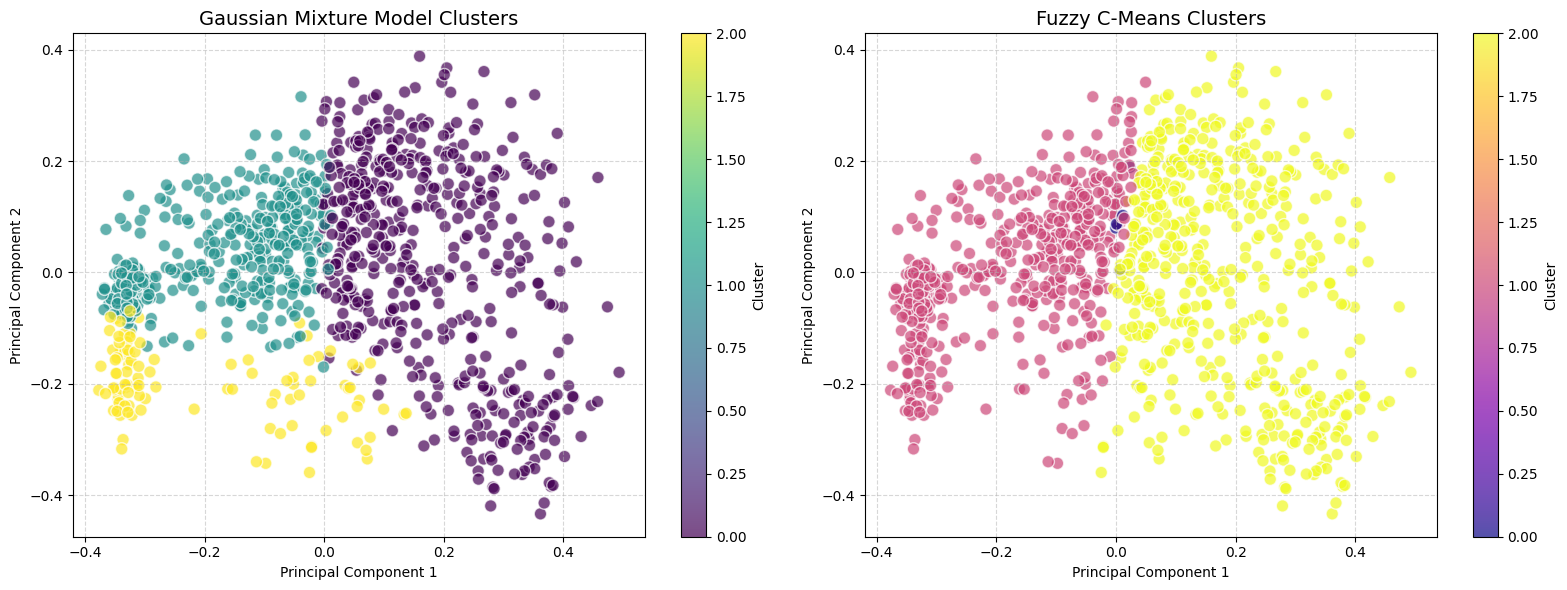

In [30]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("=" * 40)
print("--- Model Comparison Statistics ---")
print("=" * 40)

# 1. Time Comparison
print(f"Time Taken - GMM: {gmm_time:.4f} seconds")
print(f"Time Taken - FCM: {fcm_time:.4f} seconds")
print("-" * 40)

# 2. Clustering Quality Comparison (Silhouette Score)
gmm_silhouette = silhouette_score(vec3, gmm_labels)
fcm_silhouette = silhouette_score(vec3, fcm_labels)
print(f"Silhouette Score - GMM: {gmm_silhouette:.4f}")
print(f"Silhouette Score - FCM: {fcm_silhouette:.4f}")
print("=" * 40)

# 3. Visualizations using PCA (reducing to 2 dimensions)
pca = PCA(n_components=2, random_state=42)
reduced_features = pca.fit_transform(vec3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GMM Plot
scatter1 = axes[0].scatter(reduced_features[:, 0], reduced_features[:, 1], c=gmm_labels, cmap='viridis', alpha=0.7, edgecolors='w', s=80)
axes[0].set_title('Gaussian Mixture Model Clusters', fontsize=14)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(True, linestyle='--', alpha=0.5)
# FIX: Changed 'title' to 'label'
fig.colorbar(scatter1, ax=axes[0], label="Cluster")

# FCM Plot
scatter2 = axes[1].scatter(reduced_features[:, 0], reduced_features[:, 1], c=fcm_labels, cmap='plasma', alpha=0.7, edgecolors='w', s=80)
axes[1].set_title('Fuzzy C-Means Clusters', fontsize=14)
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].grid(True, linestyle='--', alpha=0.5)
# FIX: Changed 'title' to 'label'
fig.colorbar(scatter2, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.show()

--- Model Comparison Statistics ---
Time Taken - GMM: 13.6276 seconds
Time Taken - FCM: 0.5703 seconds
----------------------------------------
Silhouette Score - GMM: 0.0390
Silhouette Score - FCM: 0.0142


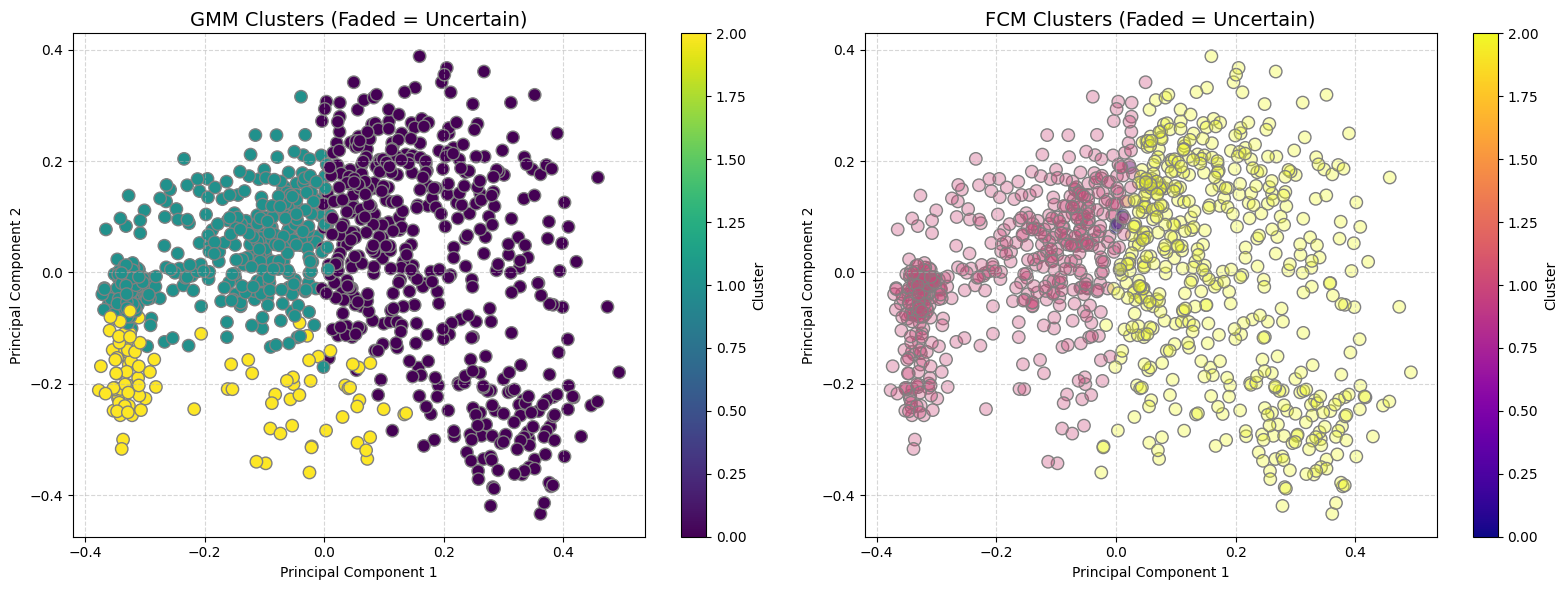

In [31]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.cm as cm
import matplotlib.colors as mcolors

print("=" * 40)
print("--- Model Comparison Statistics ---")
print("=" * 40)

# Time Comparison
print(f"Time Taken - GMM: {gmm_time:.4f} seconds")
print(f"Time Taken - FCM: {fcm_time:.4f} seconds")
print("-" * 40)

# Silhouette Score Comparison
gmm_silhouette = silhouette_score(vec3, gmm_labels)
fcm_silhouette = silhouette_score(vec3, fcm_labels)
print(f"Silhouette Score - GMM: {gmm_silhouette:.4f}")
print(f"Silhouette Score - FCM: {fcm_silhouette:.4f}")
print("=" * 40)

# Extract Probabilities for visual fading
gmm_probs = gmm.predict_proba(vec3)
gmm_max_probs = gmm_probs.max(axis=1) 
fcm_max_probs = u.max(axis=0) 

# PCA for 2D Plotting
pca = PCA(n_components=2, random_state=42)
reduced_features = pca.fit_transform(vec3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GMM Plot with Probability Alpha
cmap1 = plt.get_cmap('viridis')
norm1 = mcolors.Normalize(vmin=gmm_labels.min(), vmax=gmm_labels.max())
rgba1 = cmap1(norm1(gmm_labels))
rgba1[:, 3] = gmm_max_probs

scatter1 = axes[0].scatter(reduced_features[:, 0], reduced_features[:, 1], c=rgba1, edgecolors='gray', s=80)
axes[0].set_title('GMM Clusters (Faded = Uncertain)', fontsize=14)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(True, linestyle='--', alpha=0.5)

dummy1 = axes[0].scatter([], [], c=[], cmap='viridis', vmin=gmm_labels.min(), vmax=gmm_labels.max())
fig.colorbar(dummy1, ax=axes[0], label="Cluster")

# FCM Plot with Probability Alpha
cmap2 = plt.get_cmap('plasma')
norm2 = mcolors.Normalize(vmin=fcm_labels.min(), vmax=fcm_labels.max())
rgba2 = cmap2(norm2(fcm_labels))
rgba2[:, 3] = fcm_max_probs

scatter2 = axes[1].scatter(reduced_features[:, 0], reduced_features[:, 1], c=rgba2, edgecolors='gray', s=80)
axes[1].set_title('FCM Clusters (Faded = Uncertain)', fontsize=14)
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].grid(True, linestyle='--', alpha=0.5)

dummy2 = axes[1].scatter([], [], c=[], cmap='plasma', vmin=fcm_labels.min(), vmax=fcm_labels.max())
fig.colorbar(dummy2, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.show()

ELBOW METHOD 

Running Elbow Method (this might take a moment)...


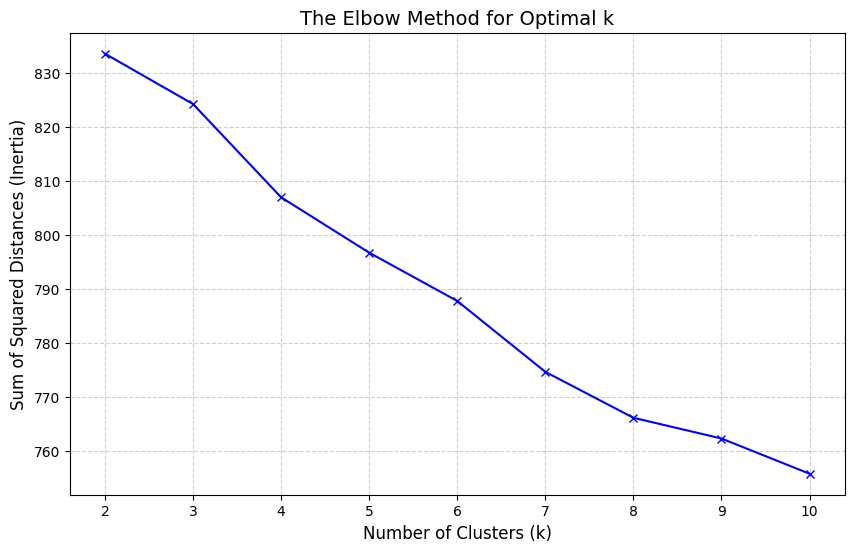

In [32]:
wcss = []
K = range(2, 11)
print("Running Elbow Method (this might take a moment)...")

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(vec3)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, wcss, 'bx-')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Sum of Squared Distances (Inertia)', fontsize=12)
plt.title('The Elbow Method for Optimal k', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(K)
plt.show()

In [33]:
import pandas as pd
from IPython.display import display

# ==========================================
# 1. FORMAT GMM PROBABILITIES
# ==========================================
# Create a DataFrame for GMM probabilities
gmm_prob_df = pd.DataFrame(
    gmm_probs, 
    columns=[f"Cluster {i} Prob" for i in range(gmm_probs.shape[1])]
)
gmm_prob_df.insert(0, "Document_Index", range(len(document)))
gmm_prob_df.insert(1, "Assigned_Cluster", gmm_labels)

# Round the probabilities to 4 decimal places for clean reading
gmm_prob_df = gmm_prob_df.round(4)

print("=" * 60)
print(" GAUSSIAN MIXTURE MODEL (GMM) - PROBABILITY MATRIX ")
print("=" * 60)
display(gmm_prob_df.head(15)) # Shows the first 15 documents

# ==========================================
# 2. FORMAT FCM PROBABILITIES
# ==========================================
# FCM outputs probabilities as (n_clusters, n_samples). 
# We must transpose it (.T) so rows are documents and columns are clusters.
fcm_probs_transposed = u.T

fcm_prob_df = pd.DataFrame(
    fcm_probs_transposed, 
    columns=[f"Cluster {i} Prob" for i in range(fcm_probs_transposed.shape[1])]
)
fcm_prob_df.insert(0, "Document_Index", range(len(document)))
fcm_prob_df.insert(1, "Assigned_Cluster", fcm_labels)

# Round the probabilities to 4 decimal places
fcm_prob_df = fcm_prob_df.round(4)

print("\n" + "=" * 60)
print(" FUZZY C-MEANS (FCM) - PROBABILITY MATRIX ")
print("=" * 60)
display(fcm_prob_df.head(15)) # Shows the first 15 documents

 GAUSSIAN MIXTURE MODEL (GMM) - PROBABILITY MATRIX 


,Document_Index,Assigned_Cluster,Cluster 0 Prob,Cluster 1 Prob,Cluster 2 Prob
0,0,1,0.0,1.0,0.0
1,1,1,0.0,1.0,0.0
2,2,1,0.0,1.0,0.0
3,3,0,1.0,0.0,0.0
4,4,0,1.0,0.0,0.0
5,5,0,1.0,0.0,0.0
6,6,0,1.0,0.0,0.0
7,7,0,1.0,0.0,0.0
8,8,0,1.0,0.0,0.0
9,9,1,0.0,1.0,0.0



 FUZZY C-MEANS (FCM) - PROBABILITY MATRIX 


,Document_Index,Assigned_Cluster,Cluster 0 Prob,Cluster 1 Prob,Cluster 2 Prob
0,0,1,0.3333,0.3334,0.3332
1,1,1,0.3333,0.3333,0.3333
2,2,1,0.3333,0.3334,0.3333
3,3,2,0.3333,0.3333,0.3334
4,4,1,0.3333,0.3334,0.3333
5,5,2,0.3333,0.3333,0.3334
6,6,2,0.3333,0.3331,0.3335
7,7,2,0.3333,0.3333,0.3334
8,8,2,0.3333,0.3332,0.3335
9,9,1,0.3333,0.3334,0.3333


In [39]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from IPython.display import display

# 1. Reduce dimensions first so GMM math doesn't explode to 1.0 and 0.0
# We reduce from thousands of words down to 10 main components
pca_for_gmm = PCA(n_components=10, random_state=42)
vec3_reduced = pca_for_gmm.fit_transform(vec3)

# 2. Fit a new GMM on this reduced, denser data
gmm_soft = GaussianMixture(n_components=5, random_state=42)
gmm_soft.fit(vec3_reduced)

# 3. Get the new, softer probabilities
soft_probs = gmm_soft.predict_proba(vec3_reduced)
soft_labels = gmm_soft.predict(vec3_reduced)

# 4. Format into a beautiful table
soft_prob_df = pd.DataFrame(
    soft_probs, 
    columns=[f"Cluster {i} Prob" for i in range(soft_probs.shape[1])]
)
soft_prob_df.insert(0, "Document_Index", range(len(document)))
soft_prob_df.insert(1, "Assigned_Cluster", soft_labels)

soft_prob_df = soft_prob_df.round(4)

print("=" * 60)
print(" GMM PROBABILITIES (AFTER PCA DIMENSION REDUCTION) ")
print("=" * 60)
display(soft_prob_df.head(15))

 GMM PROBABILITIES (AFTER PCA DIMENSION REDUCTION) 


,Document_Index,Assigned_Cluster,Cluster 0 Prob,Cluster 1 Prob,Cluster 2 Prob,Cluster 3 Prob,Cluster 4 Prob
0,0,3,0.0000,0.0000,0.0000,1.0,0.0000
1,1,1,0.0315,0.9685,0.0000,0.0,0.0000
2,2,4,0.0104,0.0074,0.0000,0.0,0.9822
3,3,1,0.0000,1.0000,0.0000,0.0,0.0000
4,4,1,0.0000,1.0000,0.0000,0.0,0.0000
5,5,1,0.0000,0.8827,0.0000,0.0,0.1173
6,6,0,1.0000,0.0000,0.0000,0.0,0.0000
7,7,0,1.0000,0.0000,0.0000,0.0,0.0000
8,8,0,1.0000,0.0000,0.0000,0.0,0.0000
9,9,1,0.0000,1.0000,0.0000,0.0,0.0000


In [40]:
import skfuzzy as fuzz

# 1. Use the PCA-reduced data we already created for GMM (10 dimensions instead of thousands)
# FCM needs the data shaped as (features, samples), so we transpose it (.T)
alldata_reduced = np.vstack(vec3_reduced.T)

# 2. Run FCM on the reduced data, and lower fuzziness 'm' from 2.0 to 1.2
print("Running PCA-Reduced Fuzzy C-Means...")
cntr_soft, u_soft, u0_soft, d_soft, jm_soft, p_soft, fpc_soft = fuzz.cluster.cmeans(
    alldata_reduced, c=5, m=1.2, error=0.005, maxiter=1000, init=None
)

# 3. Format into a table
fcm_soft_probs_transposed = u_soft.T
fcm_soft_labels = np.argmax(u_soft, axis=0)

fcm_soft_prob_df = pd.DataFrame(
    fcm_soft_probs_transposed, 
    columns=[f"Cluster {i} Prob" for i in range(fcm_soft_probs_transposed.shape[1])]
)
fcm_soft_prob_df.insert(0, "Document_Index", range(len(document)))
fcm_soft_prob_df.insert(1, "Assigned_Cluster", fcm_soft_labels)

fcm_soft_prob_df = fcm_soft_prob_df.round(4)

print("=" * 60)
print(" FCM PROBABILITIES (AFTER PCA & LOWER FUZZINESS) ")
print("=" * 60)
display(fcm_soft_prob_df.head(15))

Running PCA-Reduced Fuzzy C-Means...
 FCM PROBABILITIES (AFTER PCA & LOWER FUZZINESS) 


,Document_Index,Assigned_Cluster,Cluster 0 Prob,Cluster 1 Prob,Cluster 2 Prob,Cluster 3 Prob,Cluster 4 Prob
0,0,1,0.0000,1.0000,0.0000,0.0000,0.0000
1,1,3,0.2861,0.1288,0.2281,0.3507,0.0064
2,2,0,0.7271,0.0468,0.1568,0.0691,0.0003
3,3,3,0.1660,0.0499,0.2902,0.4607,0.0332
4,4,3,0.0085,0.0017,0.0035,0.9858,0.0004
5,5,2,0.0206,0.0014,0.8450,0.1284,0.0045
6,6,4,0.0005,0.0001,0.0006,0.0002,0.9986
7,7,4,0.0464,0.0075,0.0130,0.0656,0.8675
8,8,4,0.0001,0.0000,0.0001,0.0001,0.9997
9,9,3,0.3309,0.2465,0.0168,0.4024,0.0035


--- NEW MODEL COMPARISON (PCA-REDUCED) ---
Silhouette Score - New GMM: 0.1517
Silhouette Score - New FCM: 0.1983


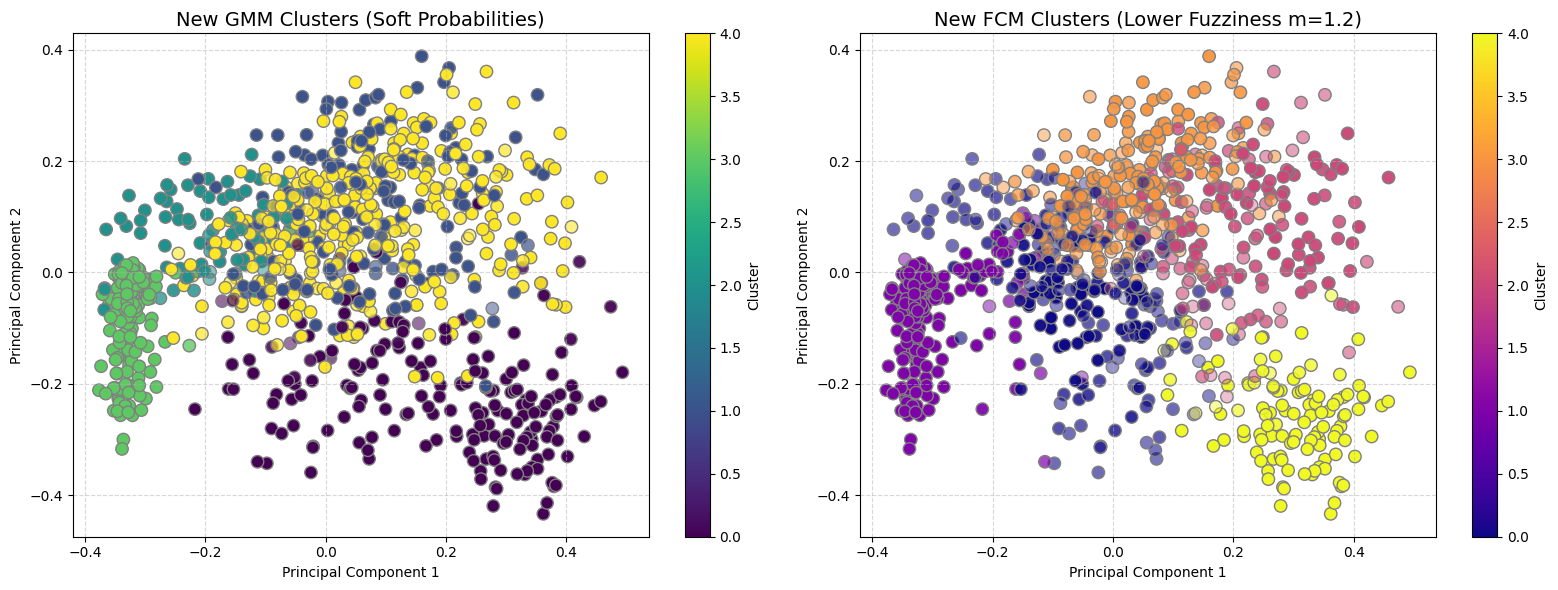

In [41]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

print("=" * 40)
print("--- NEW MODEL COMPARISON (PCA-REDUCED) ---")
print("=" * 40)

# 1. Silhouette Scores 
# We calculate this on the 10-dimensional reduced data that the models were trained on
gmm_soft_silhouette = silhouette_score(vec3_reduced, soft_labels)
fcm_soft_silhouette = silhouette_score(vec3_reduced, fcm_soft_labels)

print(f"Silhouette Score - New GMM: {gmm_soft_silhouette:.4f}")
print(f"Silhouette Score - New FCM: {fcm_soft_silhouette:.4f}")
print("=" * 40)

# 2. Visualizations
# We can just use the first two columns of our 10D vec3_reduced for the X and Y axes
x_coords = vec3_reduced[:, 0]
y_coords = vec3_reduced[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------------------------
# New GMM Plot 
# --------------------------
gmm_soft_max_probs = soft_probs.max(axis=1)

cmap1 = plt.get_cmap('viridis')
norm1 = mcolors.Normalize(vmin=soft_labels.min(), vmax=soft_labels.max())
rgba1 = cmap1(norm1(soft_labels))
rgba1[:, 3] = gmm_soft_max_probs # Apply the new, softer probabilities to transparency

scatter1 = axes[0].scatter(x_coords, y_coords, c=rgba1, edgecolors='gray', s=80)
axes[0].set_title('New GMM Clusters (Soft Probabilities)', fontsize=14)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Colorbar for GMM
dummy1 = axes[0].scatter([], [], c=[], cmap='viridis', vmin=soft_labels.min(), vmax=soft_labels.max())
fig.colorbar(dummy1, ax=axes[0], label="Cluster")


# --------------------------
# New FCM Plot 
# --------------------------
fcm_soft_max_probs = u_soft.max(axis=0)

cmap2 = plt.get_cmap('plasma')
norm2 = mcolors.Normalize(vmin=fcm_soft_labels.min(), vmax=fcm_soft_labels.max())
rgba2 = cmap2(norm2(fcm_soft_labels))
rgba2[:, 3] = fcm_soft_max_probs # Apply the more confident probabilities to transparency

scatter2 = axes[1].scatter(x_coords, y_coords, c=rgba2, edgecolors='gray', s=80)
axes[1].set_title('New FCM Clusters (Lower Fuzziness m=1.2)', fontsize=14)
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Colorbar for FCM
dummy2 = axes[1].scatter([], [], c=[], cmap='plasma', vmin=fcm_soft_labels.min(), vmax=fcm_soft_labels.max())
fig.colorbar(dummy2, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.show()